11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model... (This will take about 30 seconds)
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8777 - loss: 0.4318
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9656 - loss: 0.1187
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9773 - loss: 0.0757
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0574
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9872 - loss: 0.0443


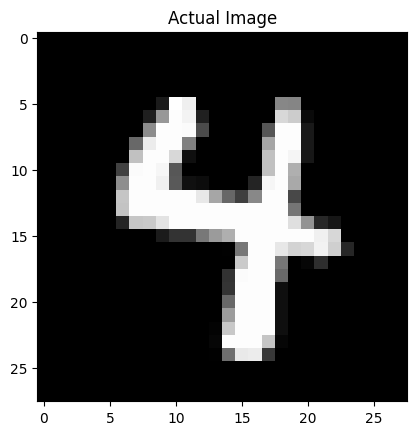

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
-----------------------------
ACTUAL NUMBER: 4
AI PREDICTED:  4
-----------------------------


In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD DATA
# MNIST is a dataset of 70,000 handwritten digits (0-9)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# 2. PREPROCESSING
# Normalize pixel values from 0-255 to 0-1 (AI learns faster with small numbers)
X_train = X_train / 255.0
X_test = X_test / 255.0

# 3. BUILD THE MODEL (The "Brain")
model = keras.Sequential([
    # Flatten: Turns the 28x28 square image into a long line of 784 pixels
    keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer: 128 neurons that figure out patterns (loops, lines)
    keras.layers.Dense(128, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9)
    keras.layers.Dense(10, activation='softmax')
])

# 4. COMPILE (Setup the training rules)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. TRAIN (Fit the model to the data)
print("Training the model... (This will take about 30 seconds)")
model.fit(X_train, y_train, epochs=5)

# 6. TEST & VISUALIZE
# Let's pick a random image from the test set and see if the AI gets it right
import random
idx = random.randint(0, len(X_test))
plt.imshow(X_test[idx], cmap='gray')
plt.title("Actual Image")
plt.show()

# Make a prediction
prediction = model.predict(X_test[idx].reshape(1, 28, 28))
predicted_number = np.argmax(prediction)

print(f"-----------------------------")
print(f"ACTUAL NUMBER: {y_test[idx]}")
print(f"AI PREDICTED:  {predicted_number}")
print(f"-----------------------------")

# Save the model (Optional, but good for real apps)
model.save('digit_recognizer_model.keras')